In [ ]:
# Shared project setup for imports and file locations
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def resolve_path(path):
    candidate = Path(path)
    if candidate.exists():
        return candidate
    text = str(path).replace('\\', '/')
    name = Path(text).name
    special = {
        ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        'Ten_positive_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'positive_controls.pkl',
        'Ten_negative_controls_1119.pkl': ARTIFACTS_DIR / 'controls' / 'negative_controls.pkl',
        DATA_DIR / 'fcg.txt': DATA_DIR / 'fcg.txt',
    }
    if name in special:
        return special[name]
    matches = [p for p in PROJECT_ROOT.rglob(name) if '.ipynb_checkpoints' not in p.parts and '.git' not in p.parts]
    if len(matches) == 1:
        return matches[0]
    if (text.startswith('/Users/') or text.startswith('/home/') or ':\\' in text) and '.' not in name:
        return PROJECT_ROOT
    return candidate

from pdm_learn.preprocessing import build_density_map, density_centers, densitymap, drop_nan, extract, mut_trim, normalize, trim, trim_pairs
from pdm_learn.modeling import KFold_PR, LOOCV, LOOCV_grouped_plot, area_table, core_predict, heatmap, importance_test, ks_pvalue
from pdm_learn.simulation import eps, partition


In [1]:
import numpy as np
import pandas as pd
import json
from itertools import combinations
import itertools
import random
from collections import defaultdict
import os
import shutil
import ast
from matplotlib import pyplot as plt
import pickle
import json
from collections import defaultdict
from itertools import combinations
from itertools import permutations
from itertools import product
import pickle
from scipy.stats import kendalltau
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu
import seaborn as sns

In [2]:
from sklearn.feature_selection import mutual_info_regression

In [3]:
from sklearn.metrics import mutual_info_score
from statsmodels.stats.multitest import multipletests

In [4]:
os.chdir(PROJECT_ROOT)
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Feb 11 update'

In [6]:
pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Read in the dataframes
def DownloadAndRenaming(path):
    df = pd.read_csv(path)
    df = df.rename(columns={"Unnamed: 0": "Gene"})
    return df

cancer_complexes = pd.read_excel(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/cancer_complexes_clean.xlsx'), index_col = 0)
Gene_expression = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Gene_Expression_Trimmed.csv')
shRNA = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'shRNA_Trimmed.csv')
CRISPR = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'CRISPR_Trimmed.csv')
Gene_mutation = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Gene_Mutation_Trimmed.csv')
copy_number = DownloadAndRenaming(DATA_DIR / 'DepMap_Trimmed' / 'Copy_Number_Trimmed.csv')


cancer_complexes["Representative Genes (Core Members)"] = (cancer_complexes["Representative Genes (Core Members)"].apply(ast.literal_eval))

type(cancer_complexes["Representative Genes (Core Members)"].iloc[0])

list

In [8]:
Gene_mutation = Gene_mutation.rename(columns={"gene name": "Gene"})
Gene_mutation.columns

Index(['Gene', '127399_SOFT_TISSUE', '143B_BONE', '201T_LUNG',
       '22RV1_PROSTATE', '2313287_STOMACH', '253JBV_URINARY_TRACT',
       '253J_URINARY_TRACT', '42MGBA_CENTRAL_NERVOUS_SYSTEM', '451LU_SKIN',
       ...
       'YD15_SALIVARY_GLAND', 'YD38_UPPER_AERODIGESTIVE_TRACT',
       'YD8_UPPER_AERODIGESTIVE_TRACT', 'YH13_CENTRAL_NERVOUS_SYSTEM',
       'YKG1_CENTRAL_NERVOUS_SYSTEM', 'YMB1E_BREAST', 'YSCCC_BILIARY_TRACT',
       'YT_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'ZR751_BREAST',
       'ZR7530_BREAST'],
      dtype='object', length=1742)

In [9]:
# Read in the positive controls
with open(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/Ten_positive_controls_1119.pkl'), "rb") as f:
    Ten_positive_controls_1119 = pickle.load(f)

In [10]:
# Read in the negative controls
with open(resolve_path('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/Ten_negative_controls_1119.pkl'), "rb") as f:
    Ten_negative_controls_1119 = pickle.load(f)

In [11]:
# Convert the control dictionary to data frame
def convert2genePairDF(control_dict, controlType = ["positive", "negative"]):

    if isinstance(control_dict, pd.DataFrame):
        genePairDF = control_dict.copy()

    else: 

        if controlType == "negative":
            genePairDF = pd.DataFrame(control_dict, columns=["Gene1", "Gene2"])
        else:
            rows = []

            for complex_name, gene_pairs in control_dict.items():
                for g1, g2 in gene_pairs:
                    rows.append([g1, g2, complex_name])

            genePairDF = pd.DataFrame(rows, columns=["Gene1", "Gene2", "Complex"])

    
    return genePairDF

In [12]:
# A computation function
def bicor(x, y, c=9.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove missing values
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan

    # Median and MAD
    x_med = np.median(x)
    y_med = np.median(y)

    x_mad = np.median(np.abs(x - x_med))
    y_mad = np.median(np.abs(y - y_med))

    if x_mad == 0 or y_mad == 0:
        return np.nan

    # Standardized distances
    ux = (x - x_med) / (c * x_mad)
    uy = (y - y_med) / (c * y_mad)

    # Weights
    wx = (1 - ux**2)**2
    wy = (1 - uy**2)**2
    wx[np.abs(ux) >= 1] = 0
    wy[np.abs(uy) >= 1] = 0

    # Weighted values
    xw = (x - x_med) * wx
    yw = (y - y_med) * wy

    numerator = np.sum(xw * yw)
    denominator = np.sqrt(np.sum(xw**2) * np.sum(yw**2))

    return numerator / denominator if denominator != 0 else np.nan



In [19]:
# Write a function specifically for bicor
def biCor(genePairDF, featureMatrix1, featureMatrix2):
    commonSamples = list(featureMatrix1.columns.intersection(featureMatrix2.columns))


    copy1 = featureMatrix1[commonSamples]
    copy2 = featureMatrix2[commonSamples]
    numOfGenePairs = len(genePairDF)
    genesInCCLE = featureMatrix1['Gene'].tolist()

    bicor_values = dict()  

    for i in range(numOfGenePairs):
        gene1 = genePairDF.iloc[i]['Gene1']
        gene2 = genePairDF.iloc[i]['Gene2']

        # Retrieve the corresponding feature values
        #print(genePairDF.iloc[i])
        if gene1 in genesInCCLE and gene2 in genesInCCLE:
            gene1FeatureValue = copy1[copy1['Gene'] == gene1].iloc[:, 1:].values.flatten()
            gene2FeatureValue = copy2[copy2['Gene'] == gene2].iloc[:, 1:].values.flatten()

            x = gene1FeatureValue
            y = gene2FeatureValue
            
            bicor_val = bicor(x, y, 9.0)
            bicor_values[i] = bicor_val

    return bicor_values

In [20]:
# Function to calculate correlations
def calculate_correlations(control, matrices, matrix_pairs, control_type = ["positive", "negative"]):
    correlations = {}

    for i, (feature_matrix1, feature_matrix2) in enumerate(matrix_pairs):
        print(f"Processing {i+1}/{len(matrix_pairs)}: {feature_matrix1} vs {feature_matrix2}")
        genePairDF = convert2genePairDF(control, control_type)
        
        correlation = biCor(
            genePairDF,
            matrices[feature_matrix1],
            matrices[feature_matrix2]
        )
        
        key = f"{feature_matrix1}_{feature_matrix2}"
        correlations[key] = correlation
        print(f"{i+1} has finished: {key}")

    return correlations

### Feature Selection

In [21]:
# Because there are ~5300 gene pairs in each negative controls
# We have to first match the sample size with the positive controls
def chooseNegatives_randomly(negative_control):
    #negDF = convert2genePairDF(negative_control, "negative")
    #random_neg = negDF.sample(70)
    negDF = random.sample(negative_control,70)

    return(negDF)

#chooseNegatives_randomly(Ten_negative_controls_1119["negative_controls_1"])
randomTenNegCtr = {
    key: chooseNegatives_randomly(neg_list)
    for key, neg_list in Ten_negative_controls_1119.items()
}

len(randomTenNegCtr["negative_controls_1"])

70

In [22]:
matrices = {
    'CRISPR' : CRISPR,
    'Gene_expression' : Gene_expression,
    'shRNA' : shRNA,
    "copy_number": copy_number,
    "Gene_mutation": Gene_mutation

}

matrixNames = list(matrices.keys())
matrix_pairs = list(product(matrixNames, repeat = 2))
print(matrix_pairs)

[('CRISPR', 'CRISPR'), ('CRISPR', 'Gene_expression'), ('CRISPR', 'shRNA'), ('CRISPR', 'copy_number'), ('CRISPR', 'Gene_mutation'), ('Gene_expression', 'CRISPR'), ('Gene_expression', 'Gene_expression'), ('Gene_expression', 'shRNA'), ('Gene_expression', 'copy_number'), ('Gene_expression', 'Gene_mutation'), ('shRNA', 'CRISPR'), ('shRNA', 'Gene_expression'), ('shRNA', 'shRNA'), ('shRNA', 'copy_number'), ('shRNA', 'Gene_mutation'), ('copy_number', 'CRISPR'), ('copy_number', 'Gene_expression'), ('copy_number', 'shRNA'), ('copy_number', 'copy_number'), ('copy_number', 'Gene_mutation'), ('Gene_mutation', 'CRISPR'), ('Gene_mutation', 'Gene_expression'), ('Gene_mutation', 'shRNA'), ('Gene_mutation', 'copy_number'), ('Gene_mutation', 'Gene_mutation')]


In [23]:
feature_pair_names = []

for pair in matrix_pairs:
    feature_name = f'{pair[0]}_{pair[1]}'
    feature_pair_names.append(feature_name)

feature_pair_names

['CRISPR_CRISPR',
 'CRISPR_Gene_expression',
 'CRISPR_shRNA',
 'CRISPR_copy_number',
 'CRISPR_Gene_mutation',
 'Gene_expression_CRISPR',
 'Gene_expression_Gene_expression',
 'Gene_expression_shRNA',
 'Gene_expression_copy_number',
 'Gene_expression_Gene_mutation',
 'shRNA_CRISPR',
 'shRNA_Gene_expression',
 'shRNA_shRNA',
 'shRNA_copy_number',
 'shRNA_Gene_mutation',
 'copy_number_CRISPR',
 'copy_number_Gene_expression',
 'copy_number_shRNA',
 'copy_number_copy_number',
 'copy_number_Gene_mutation',
 'Gene_mutation_CRISPR',
 'Gene_mutation_Gene_expression',
 'Gene_mutation_shRNA',
 'Gene_mutation_copy_number',
 'Gene_mutation_Gene_mutation']

In [24]:
# Function for comparing the medians across ten positive and negative controls with Mann-Whiteney U test
def SummarizeDependencies_1(all_controls, matrices, matrix_pairs, control_type):
    bicor_summary = dict()
    for control in all_controls.keys():
        this_ctrl = all_controls[control]
        this_bicor_dependency = calculate_correlations(this_ctrl, matrices, matrix_pairs, control_type)
        bicor_summary[control] = this_bicor_dependency

    return bicor_summary

def SummarizeDependencies_2(bicor_summary):

    bicor_median_summary = dict()

    for condition, interaction_dict in bicor_summary.items():
        bicor_median_summary[condition] = {}
        for interaction_type, index_dict in interaction_dict.items():
            values = list(index_dict.values())
            bicor_median_summary[condition][interaction_type] = np.nanmedian(values)

    return bicor_median_summary 


def SummarizeDependencies_3(pos_median_summary, neg_median_summary, feature_pair_names):
    positive_everyComb_dataPoints = {}
    negative_everyComb_dataPoints = {}

    for everyComb in feature_pair_names:
        positive_everyComb_dataPoints[everyComb] = []
        negative_everyComb_dataPoints[everyComb] = []
        for i in range(10):
            thisComb_pos = pos_median_summary[f'positive_control_{i+1}'][everyComb]
            thisComb_neg = neg_median_summary[f'negative_controls_{i+1}'][everyComb]
            positive_everyComb_dataPoints[everyComb].append(thisComb_pos)
            negative_everyComb_dataPoints[everyComb].append(thisComb_neg)

    return positive_everyComb_dataPoints, negative_everyComb_dataPoints # The output should be the median for every feature (each feature should have 10 data points)


def AssessSignificance(positive_everyComb_dataPoints, negative_everyComb_dataPoints, feature_pair_names):
    significance_results = {}

    for comb in feature_pair_names:
        pos_vals = positive_everyComb_dataPoints[comb]
        neg_vals = negative_everyComb_dataPoints[comb]
        stat, p = mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
        significance_results[comb] = (stat, p)

    return significance_results 

In [25]:
# summarize into one complete function

def featureSignificance(positive_all_controls, negative_all_controls, matrices, matrix_pairs, feature_pair_names):
    # First, calculate the dependency between all gene pairs across ten controls with MI
    all_pos_bicor_summary = SummarizeDependencies_1(positive_all_controls, matrices, matrix_pairs, "positive")
    all_neg_bicor_summary = SummarizeDependencies_1(negative_all_controls, matrices, matrix_pairs, "negative")
    # Next, condense the ~70 gene pairs to one median for each control trial
    pos_median_summary = SummarizeDependencies_2(all_pos_bicor_summary)
    neg_median_summary = SummarizeDependencies_2(all_neg_bicor_summary)
    pos_everyComb_dps, neg_everyComb_dps = SummarizeDependencies_3(pos_median_summary, neg_median_summary, feature_pair_names)

    # Evaluate the significance between every feature combination
    feature_significance_results = AssessSignificance(pos_everyComb_dps, neg_everyComb_dps, feature_pair_names)

    return feature_significance_results

In [26]:
# Call the function to get the feature significance
Bicor_feature_significance_results = featureSignificance(Ten_positive_controls_1119, randomTenNegCtr, matrices, matrix_pairs, feature_pair_names)
Bicor_feature_significance_results

Processing 1/25: CRISPR vs CRISPR
1 has finished: CRISPR_CRISPR
Processing 2/25: CRISPR vs Gene_expression
2 has finished: CRISPR_Gene_expression
Processing 3/25: CRISPR vs shRNA
3 has finished: CRISPR_shRNA
Processing 4/25: CRISPR vs copy_number
4 has finished: CRISPR_copy_number
Processing 5/25: CRISPR vs Gene_mutation
5 has finished: CRISPR_Gene_mutation
Processing 6/25: Gene_expression vs CRISPR
6 has finished: Gene_expression_CRISPR
Processing 7/25: Gene_expression vs Gene_expression
7 has finished: Gene_expression_Gene_expression
Processing 8/25: Gene_expression vs shRNA
8 has finished: Gene_expression_shRNA
Processing 9/25: Gene_expression vs copy_number
9 has finished: Gene_expression_copy_number
Processing 10/25: Gene_expression vs Gene_mutation
10 has finished: Gene_expression_Gene_mutation
Processing 11/25: shRNA vs CRISPR
11 has finished: shRNA_CRISPR
Processing 12/25: shRNA vs Gene_expression
12 has finished: shRNA_Gene_expression
Processing 13/25: shRNA vs shRNA
13 has fi

/var/folders/m1/vzz8q47d5xv5yb6gx562s4q00000gn/T/ipykernel_5051/4084103511.py:19: RuntimeWarning: All-NaN slice encountered
  bicor_median_summary[condition][interaction_type] = np.nanmedian(values)


{'CRISPR_CRISPR': (100.0, 0.00018267179110955002),
 'CRISPR_Gene_expression': (65.0, 0.27303633975118835),
 'CRISPR_shRNA': (92.0, 0.0017062493689195964),
 'CRISPR_copy_number': (nan, nan),
 'CRISPR_Gene_mutation': (nan, nan),
 'Gene_expression_CRISPR': (67.0, 0.21229383619233166),
 'Gene_expression_Gene_expression': (100.0, 0.00018267179110955002),
 'Gene_expression_shRNA': (70.0, 0.14046504815835498),
 'Gene_expression_copy_number': (nan, nan),
 'Gene_expression_Gene_mutation': (nan, nan),
 'shRNA_CRISPR': (98.0, 0.0003298385207779935),
 'shRNA_Gene_expression': (64.0, 0.3074894566186813),
 'shRNA_shRNA': (100.0, 0.00018267179110955002),
 'shRNA_copy_number': (nan, nan),
 'shRNA_Gene_mutation': (nan, nan),
 'copy_number_CRISPR': (nan, nan),
 'copy_number_Gene_expression': (nan, nan),
 'copy_number_shRNA': (nan, nan),
 'copy_number_copy_number': (nan, nan),
 'copy_number_Gene_mutation': (nan, nan),
 'Gene_mutation_CRISPR': (nan, nan),
 'Gene_mutation_Gene_expression': (nan, nan),
 'Ge

In [29]:
# Use a data frame to summarize the significance
Bicor_feature_significance_df = pd.DataFrame(Bicor_feature_significance_results)
Bicor_feature_significance_df.index = ["U-statistics", "p-val"]
Bicor_feature_significance_df = Bicor_feature_significance_df.T
Bicor_feature_significance_df = Bicor_feature_significance_df.dropna()
Bicor_feature_significance_df

,U-statistics,p-val
CRISPR_CRISPR,100.0,0.000183
CRISPR_Gene_expression,65.0,0.273036
CRISPR_shRNA,92.0,0.001706
Gene_expression_CRISPR,67.0,0.212294
Gene_expression_Gene_expression,100.0,0.000183
Gene_expression_shRNA,70.0,0.140465
shRNA_CRISPR,98.0,0.000330
shRNA_Gene_expression,64.0,0.307489
shRNA_shRNA,100.0,0.000183


In [30]:
# We need to do FDR adjustment for 25 independent testings
Bicor_feature_significance_df["adj_p-val"] = multipletests(Bicor_feature_significance_df["p-val"], method="fdr_bh")[1]
Bicor_feature_significance_df

,U-statistics,p-val,adj_p-val
CRISPR_CRISPR,100.0,0.000183,0.000548
CRISPR_Gene_expression,65.0,0.273036,0.307166
CRISPR_shRNA,92.0,0.001706,0.003071
Gene_expression_CRISPR,67.0,0.212294,0.272949
Gene_expression_Gene_expression,100.0,0.000183,0.000548
Gene_expression_shRNA,70.0,0.140465,0.210698
shRNA_CRISPR,98.0,0.000330,0.000742
shRNA_Gene_expression,64.0,0.307489,0.307489
shRNA_shRNA,100.0,0.000183,0.000548


In [31]:
Bicor_feature_significance_df.to_csv(ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / 'Bicor_feature_sig_df_0217.csv', index = True)

In [32]:
Bicor_feature_significance_df = pd.read_csv(ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / ARTIFACTS_DIR / 'results' / 'Bicor_feature_sig_df_0217.csv')
Bicor_feature_significance_df.head()

,Unnamed: 0,U-statistics,p-val,adj_p-val
0,CRISPR_CRISPR,100.0,0.000183,0.000548
1,CRISPR_Gene_expression,65.0,0.273036,0.307166
2,CRISPR_shRNA,92.0,0.001706,0.003071
3,Gene_expression_CRISPR,67.0,0.212294,0.272949
4,Gene_expression_Gene_expression,100.0,0.000183,0.000548


In [33]:
datasets = ["CRISPR", "Gene_expression", "shRNA"]

def split_feature(x):
    for d in datasets:
        if x.startswith(d + "_"):
            return pd.Series([d, x[len(d)+1:]])
    return pd.Series([None, None])

Bicor_feature_significance_df[['Dataset1', 'Dataset2']] = Bicor_feature_significance_df['Unnamed: 0'].apply(split_feature)
Bicor_feature_significance_df.head()

,Unnamed: 0,U-statistics,p-val,adj_p-val,Dataset1,Dataset2
0,CRISPR_CRISPR,100.0,0.000183,0.000548,CRISPR,CRISPR
1,CRISPR_Gene_expression,65.0,0.273036,0.307166,CRISPR,Gene_expression
2,CRISPR_shRNA,92.0,0.001706,0.003071,CRISPR,shRNA
3,Gene_expression_CRISPR,67.0,0.212294,0.272949,Gene_expression,CRISPR
4,Gene_expression_Gene_expression,100.0,0.000183,0.000548,Gene_expression,Gene_expression


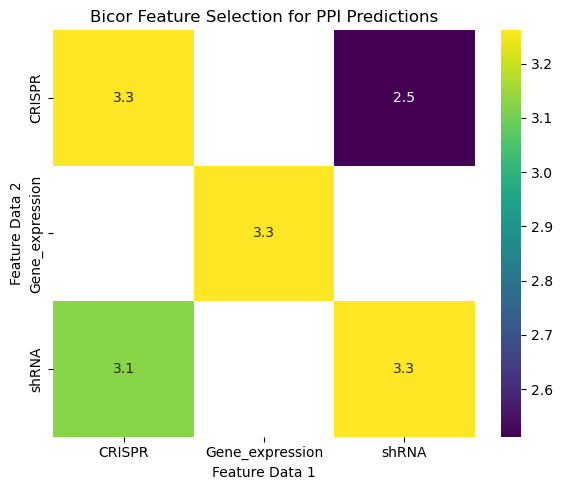

In [34]:
heatmap_df = Bicor_feature_significance_df.pivot(index='Dataset1',
                      columns='Dataset2',
                      values='adj_p-val')

heatmap_values = -np.log10(heatmap_df)


plt.figure(figsize=(6,5))
threshold = heatmap_df > 0.05
sns.heatmap(heatmap_values,
            annot=True,
            cmap='viridis',
            mask=threshold)

plt.title("Bicor Feature Selection for PPI Predictions")
plt.xlabel("Feature Data 1")
plt.ylabel("Feature Data 2")
plt.tight_layout()
plt.savefig("Bicor Feature Selection for PPI Predictions.png", dpi = 300)
plt.show()